# Student Performance EDA
Exploratory Data Analysis on Student Performance Dataset

## Step 1: Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Step 2: Load Dataset

In [20]:
df = pd.read_csv('../data/StudentsPerformance (3).csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Step 3: Basic Info

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [22]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [23]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## Step 4: Univariate Analysis

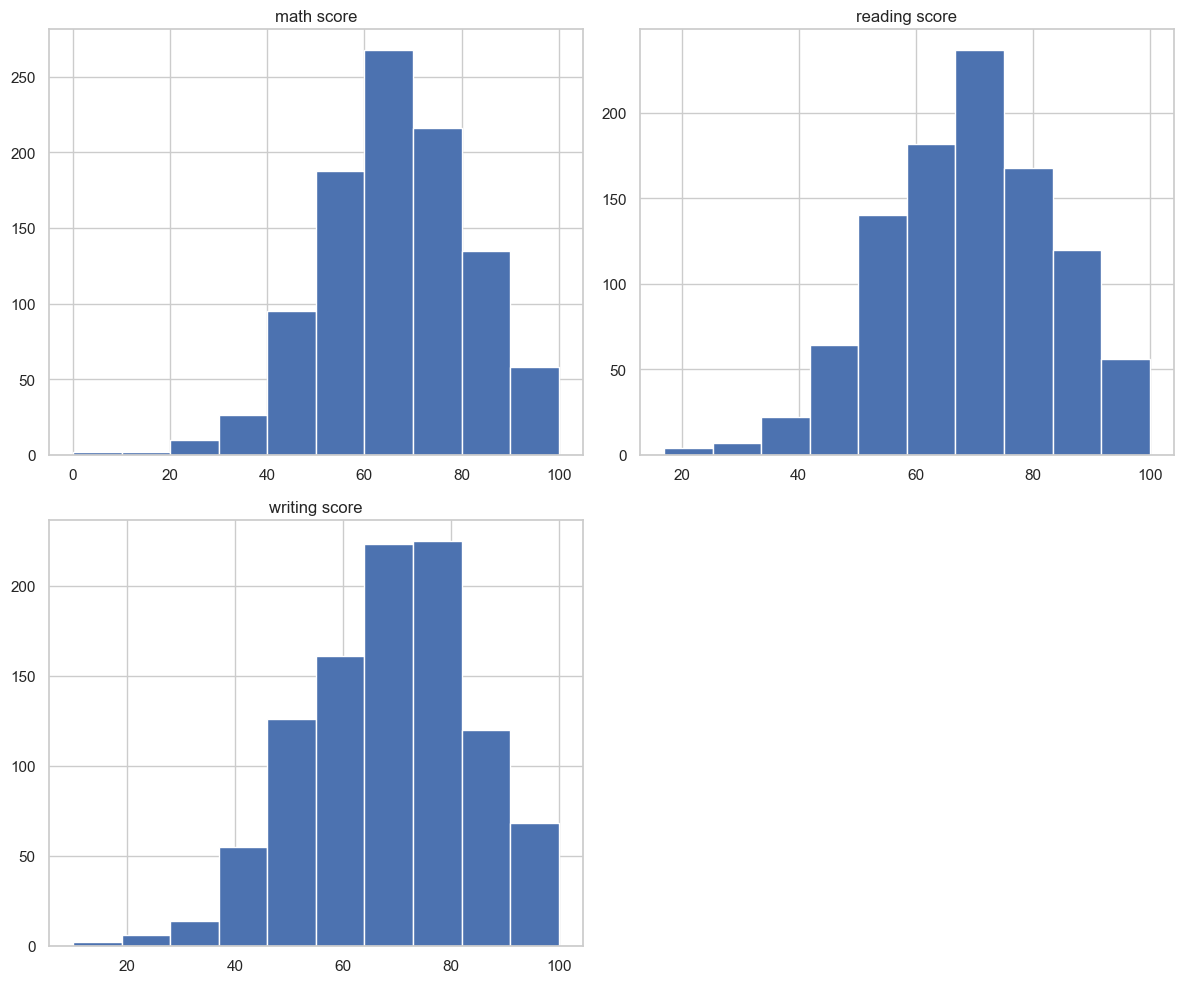

In [24]:
# Select only numeric columns for histograms
numeric_cols = df.select_dtypes(include=[np.number])
numeric_cols.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

## Data Preparation for Correlation
Select only numeric columns for correlation analysis

In [25]:
# Get numeric columns
numeric_cols = df.select_dtypes(include=[np.number])
print(f"Numeric columns for correlation: {list(numeric_cols.columns)}")
print(f"\nShape: {numeric_cols.shape}")

Numeric columns for correlation: ['math score', 'reading score', 'writing score']

Shape: (1000, 3)


## Step 5: Correlation Heatmap

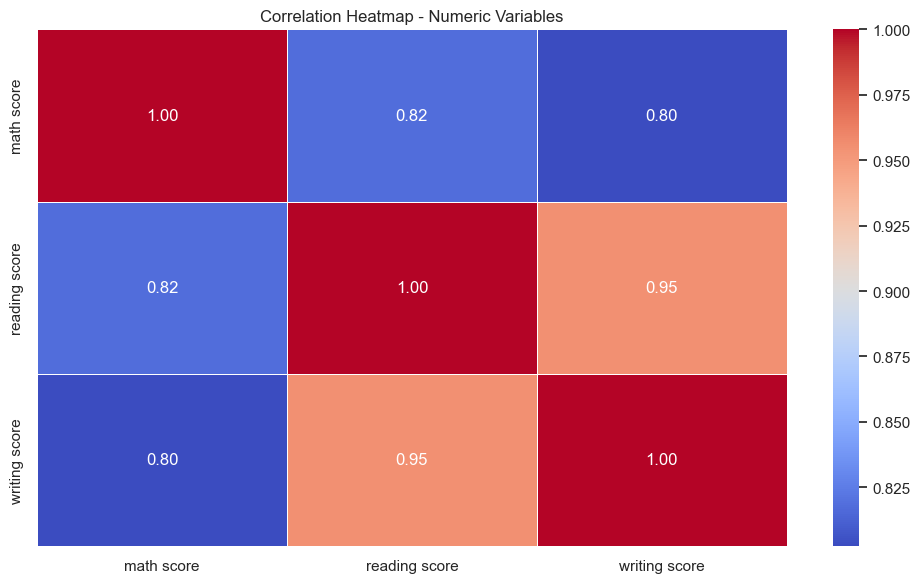

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Numeric Variables')
plt.tight_layout()
plt.show()

## Step 6: Key Visualizations

### Gender vs Performance

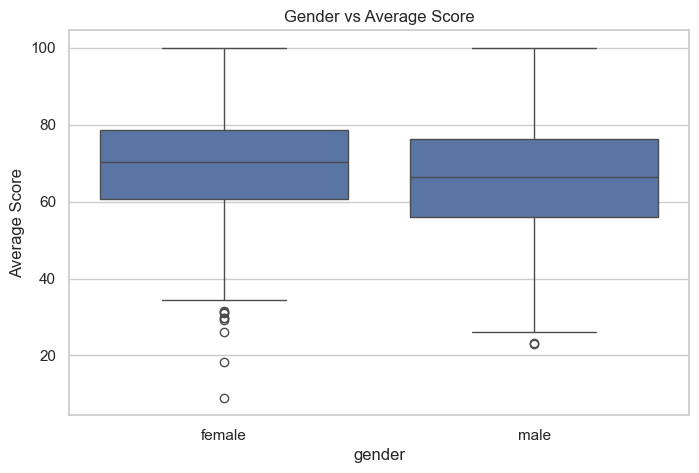

In [27]:
plt.figure(figsize=(8,5))
# Using average of all scores as performance metric
df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)
sns.boxplot(x='gender', y='average_score', data=df)
plt.title('Gender vs Average Score')
plt.ylabel('Average Score')
plt.show()

### Test Preparation Course Impact

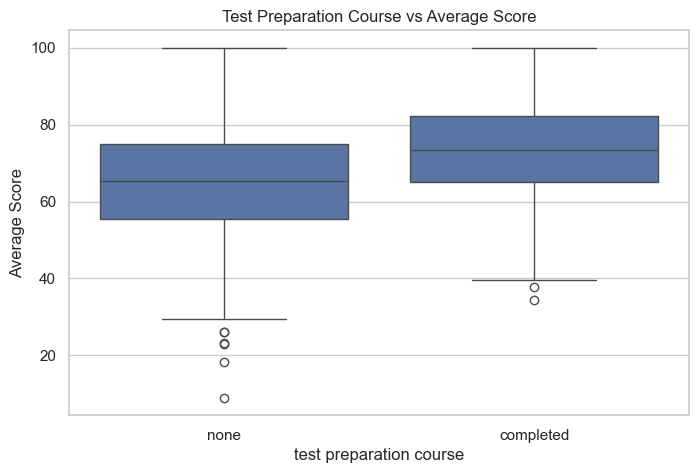

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x='test preparation course', y='average_score', data=df)
plt.title('Test Preparation Course vs Average Score')
plt.ylabel('Average Score')
plt.show()

### Parental Education Level Impact

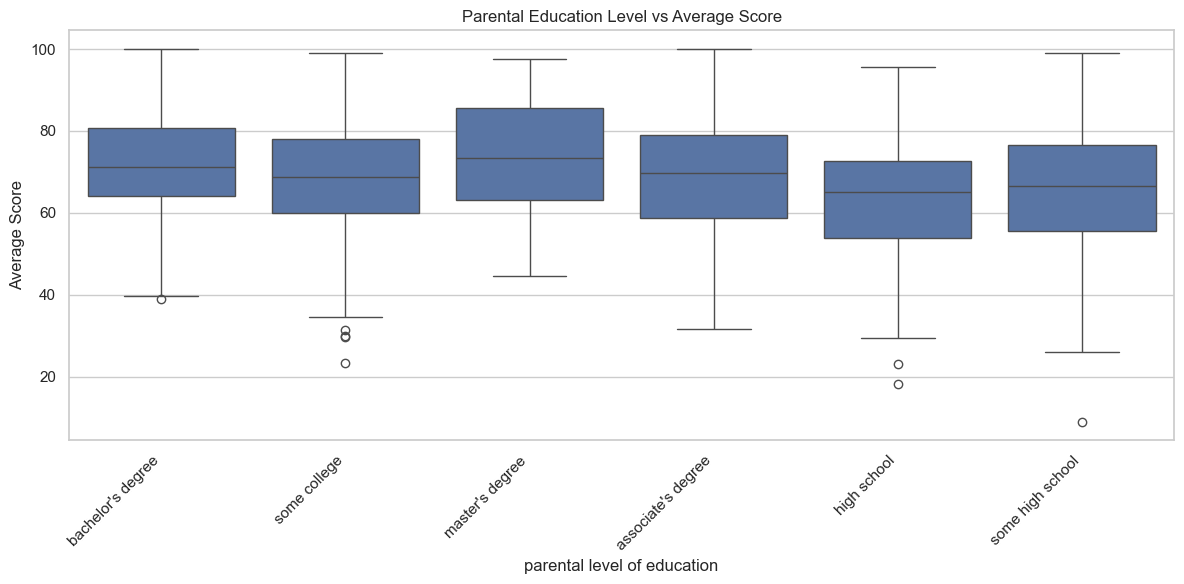

In [29]:
plt.figure(figsize=(12,6))
sns.boxplot(x='parental level of education', y='average_score', data=df)
plt.title('Parental Education Level vs Average Score')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Score Distribution by Subject

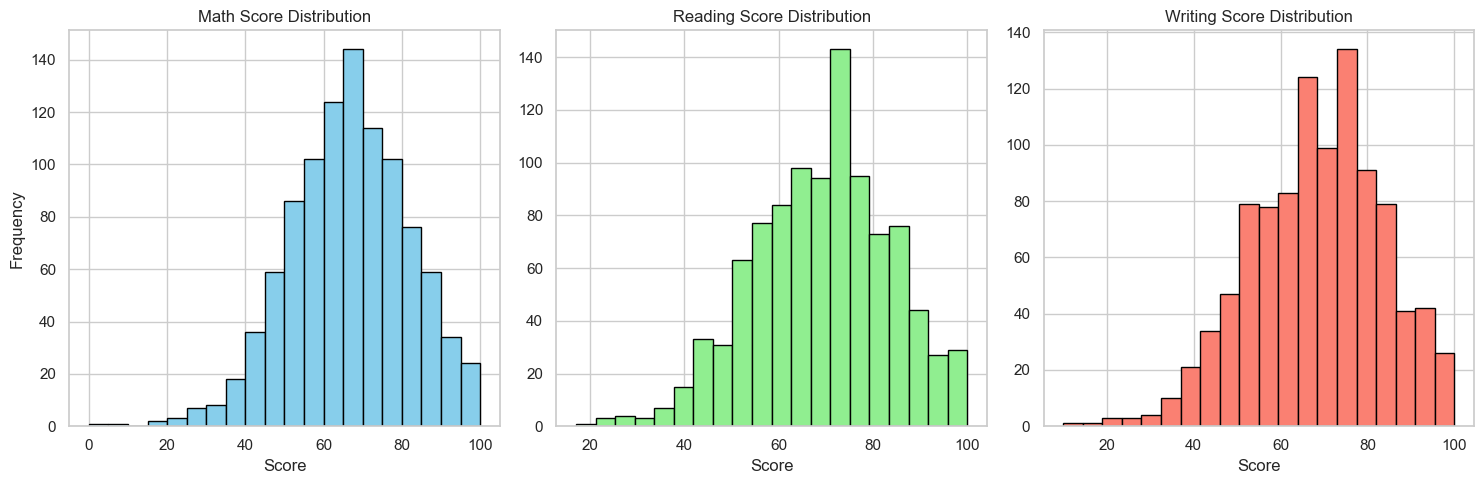

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df['math score'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Math Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['reading score'], bins=20, color='lightgreen', edgecolor='black')
axes[1].set_title('Reading Score Distribution')
axes[1].set_xlabel('Score')

axes[2].hist(df['writing score'], bins=20, color='salmon', edgecolor='black')
axes[2].set_title('Writing Score Distribution')
axes[2].set_xlabel('Score')

plt.tight_layout()
plt.show()